# IAA Project - Student Dropout

Este notebook serve como base para o projeto:
- carregar e inspecionar dados;
- preparar objetivo binario (`Dropout` vs `Non-Dropout`) e multiclasse;
- correr modelos baseline comparaveis;
- preparar secao de fairness e reflexao etica.

In [1]:
# Cell 1 - Setup geral
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option('display.max_columns', 80)
sns.set_theme(style='whitegrid')

print('Setup concluido.')

Setup concluido.


## 1) Localizar e carregar dataset

A celula abaixo procura automaticamente um ficheiro `.csv` em `data/`.
Se o teu dataset estiver noutro sitio, ajusta `DATA_PATH` manualmente.

In [ ]:
# Cell 2 - Paths e carregamento de dados
PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / 'data'

def find_first_csv(data_dir: Path):
    if not data_dir.exists():
        return None
    csv_files = sorted(data_dir.glob('*.csv'))
    return csv_files[0] if csv_files else None

DATA_PATH = find_first_csv(DATA_DIR)

if DATA_PATH is None:
    print("Não foi encontrado nenhum CSV em 'data/'.")
    print('Cria a pasta data/ e insere o dataset, ou define DATA_PATH manualmente.')
else:
    print(f'Dataset encontrado: {DATA_PATH}')

df = pd.read_csv(DATA_PATH) if DATA_PATH is not None else pd.DataFrame()
print('Shape:', df.shape)

Dataset encontrado: /Users/goncalosimoes/Desktop/EI3A2S/IAA/Práticas/project/iaa-project-1/data/dataset.csv
Shape: (4424, 35)


## 2) EDA rapida

In [3]:
# Cell 3 - Primeira inspeccao
if df.empty:
    print('DataFrame vazio. Carrega primeiro o dataset.')
else:
    display(df.head())
    print('\nTipos de dados:')
    display(df.dtypes.value_counts())
    print('\nMissing values (top 10):')
    display(df.isna().sum().sort_values(ascending=False).head(10))

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,8,5,2,1,1,1,13,10,6,10,1,0,0,1,1,0,20,0,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,6,1,11,1,1,1,1,3,4,4,1,0,0,0,1,0,19,0,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,5,1,1,1,22,27,10,10,1,0,0,0,1,0,19,0,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,8,2,15,1,1,1,23,27,6,4,1,0,0,1,0,0,20,0,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,12,1,3,0,1,1,22,28,10,10,0,0,0,1,0,0,45,0,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate



Tipos de dados:


int64      29
float64     5
object      1
Name: count, dtype: int64


Missing values (top 10):


Marital status                                    0
Curricular units 2nd sem (enrolled)               0
Curricular units 1st sem (enrolled)               0
Curricular units 1st sem (evaluations)            0
Curricular units 1st sem (approved)               0
Curricular units 1st sem (grade)                  0
Curricular units 1st sem (without evaluations)    0
Curricular units 2nd sem (credited)               0
Curricular units 2nd sem (evaluations)            0
International                                     0
dtype: int64

Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

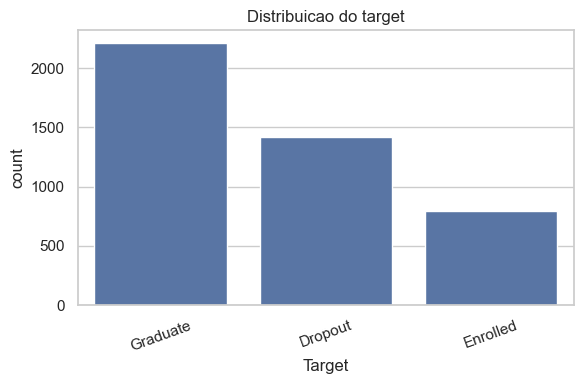

In [4]:
# Cell 4 - Distribuicao do target (ajusta o nome da coluna se necessario)
TARGET_COL = 'Target'

if df.empty:
    print('DataFrame vazio.')
elif TARGET_COL not in df.columns:
    print(f"Coluna '{TARGET_COL}' nao encontrada.")
    print('Colunas disponiveis:')
    display(df.columns.to_series().head(30))
else:
    display(df[TARGET_COL].value_counts(dropna=False))
    plt.figure(figsize=(6, 4))
    sns.countplot(data=df, x=TARGET_COL, order=df[TARGET_COL].value_counts().index)
    plt.title('Distribuicao do target')
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

## 3) Preparacao de alvo binario e split

In [5]:
# Cell 5 - Preparacao de dados para modelacao
if df.empty or TARGET_COL not in df.columns:
    print('Nao e possivel preparar dados sem dataset/target valido.')
else:
    work_df = df.copy()

    # Objetivo principal: Dropout vs Non-Dropout
    work_df['target_binary'] = np.where(work_df[TARGET_COL].astype(str).str.lower() == 'dropout', 1, 0)

    X = work_df.drop(columns=[TARGET_COL, 'target_binary'])
    y_binary = work_df['target_binary']
    y_multi = work_df[TARGET_COL]

    X_train, X_test, yb_train, yb_test = train_test_split(
        X, y_binary, test_size=0.2, random_state=RANDOM_STATE, stratify=y_binary
    )

    _, _, ym_train, ym_test = train_test_split(
        X, y_multi, test_size=0.2, random_state=RANDOM_STATE, stratify=y_multi
    )

    print('X_train:', X_train.shape, '| X_test:', X_test.shape)
    print('Distribuicao binaria (train):')
    display(yb_train.value_counts(normalize=True).rename('proportion'))

X_train: (3539, 34) | X_test: (885, 34)
Distribuicao binaria (train):


target_binary
0    0.678723
1    0.321277
Name: proportion, dtype: float64

## 4) Baselines (Logistic Regression + Random Forest)

In [6]:
# Cell 6 - Pipeline e avaliacao em CV (binario)
if df.empty or TARGET_COL not in df.columns:
    print('Dados insuficientes para treinar modelos.')
else:
    numeric_selector = make_column_selector(dtype_include=np.number)
    categorical_selector = make_column_selector(dtype_exclude=np.number)

    numeric_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])

    categorical_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ])

    preprocessor = ColumnTransformer([
        ('num', numeric_pipe, numeric_selector),
        ('cat', categorical_pipe, categorical_selector)
    ])

    models = {
        'log_reg': LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE),
        'rf': RandomForestClassifier(n_estimators=400, class_weight='balanced', random_state=RANDOM_STATE)
    }

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    scoring = ['accuracy', 'f1', 'precision', 'recall', 'roc_auc']

    cv_results = []

    for name, model in models.items():
        pipe = Pipeline([
            ('prep', preprocessor),
            ('model', model)
        ])

        scores = cross_validate(pipe, X_train, yb_train, cv=cv, scoring=scoring, n_jobs=-1)
        summary = {metric: float(np.mean(scores[f'test_{metric}'])) for metric in scoring}
        summary['model'] = name
        cv_results.append(summary)

    cv_df = pd.DataFrame(cv_results).set_index('model').sort_values('f1', ascending=False)
    display(cv_df)

,accuracy,f1,precision,recall,roc_auc
model,,,,,
log_reg,0.861262,0.790835,0.769845,0.814433,0.918718
rf,0.872566,0.779140,0.878892,0.700066,0.916649


Melhor modelo: log_reg

Classification report (binario):
              precision    recall  f1-score   support

           0     0.9167    0.8968    0.9066       601
           1     0.7912    0.8275    0.8090       284

    accuracy                         0.8746       885
   macro avg     0.8540    0.8622    0.8578       885
weighted avg     0.8764    0.8746    0.8753       885



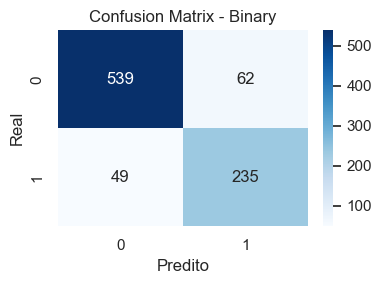

In [7]:
# Cell 7 - Avaliacao holdout do melhor modelo (binario)
if df.empty or TARGET_COL not in df.columns:
    print('Dados insuficientes para avaliacao final.')
else:
    best_model_name = cv_df.index[0]
    best_model = models[best_model_name]

    best_pipe = Pipeline([
        ('prep', preprocessor),
        ('model', best_model)
    ])

    best_pipe.fit(X_train, yb_train)
    yb_pred = best_pipe.predict(X_test)

    print('Melhor modelo:', best_model_name)
    print('\nClassification report (binario):')
    print(classification_report(yb_test, yb_pred, digits=4))

    cm = confusion_matrix(yb_test, yb_pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix - Binary')
    plt.xlabel('Predito')
    plt.ylabel('Real')
    plt.tight_layout()
    plt.show()

## 5) Fairness diagnostics (template)

Completa esta secao com os grupos relevantes (ex.: genero, escaloes socioeconomicos, idade).

In [8]:
# Cell 8 - Funcao util para metricas por subgrupo
from sklearn.metrics import f1_score, recall_score, precision_score

def subgroup_binary_metrics(df_eval, y_true_col, y_pred_col, group_col):
    rows = []
    for g, part in df_eval.groupby(group_col):
        if part[y_true_col].nunique() < 2:
            continue
        rows.append({
            group_col: g,
            'n': len(part),
            'f1': f1_score(part[y_true_col], part[y_pred_col]),
            'precision': precision_score(part[y_true_col], part[y_pred_col]),
            'recall': recall_score(part[y_true_col], part[y_pred_col])
        })
    return pd.DataFrame(rows).sort_values('n', ascending=False)

print('Template fairness pronto.')

Template fairness pronto.


## 6) Proximos passos

- Confirmar nome real da coluna target e codificacoes;
- Adicionar baseline multiclasse com metricas macro;
- Definir protocolo final de validacao e tuning;
- Incluir comparacao com/sem features socioeconomicas;
- Documentar limitacoes e implicacoes eticas.